# Stability — feature-importance distance, parameter distance

Bootstraps each model to see how much its feature importances, parameters, and AUC move
under resampled training data, for whichever models have a `models/<name>_model.py` file
so far. Bootstrapping means refitting `N_BOOT` times, so compute cost is the main
constraint here — see the per-model `N_BOOT`/`EVAL_SAMPLE_SIZE` further down.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("../..").resolve()))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

import common_metrics as cm

NB_OUTPUT_DIR = cm.OUTPUT_DIR / "stability"
NB_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cm.report_status()

Ready:   ['xgboost', 'logreg', 'tabpfn']
Waiting: (none — all models in)


## Load data

In [2]:
train_df = cm.load_split("train")
test_df = cm.load_split("test")

X_train, y_train = cm.get_X_y(train_df)
X_test, y_test = cm.get_X_y(test_df)

print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (6394039, 31), test: (1368986, 31)


## Feature-importance distance + performance stability — one bootstrap, both numbers

`d(f1, f2) = ||φ(f1) - φ(f2)||₂`, via `common_metrics.importance_vector`. AUC spread is
bundled into the same loop since both need the same bootstrap resamples — one fit per
iteration gets you both numbers instead of fitting twice.

**Raw vs. rank distance**: XGBoost's gain, logreg's coefficients, and permutation importance
are not on the same numeric scale, so the raw `d(f1,f2)` above is only meaningful *within* a
model type, not across them (XGBoost's raw distances run ~200x larger than logreg's purely
from units, not from being "less stable"). `common_metrics.importance_rank_distance` reranks
each vector first, which removes the unit mismatch — both are computed and kept, raw for
within-model magnitude, rank for cross-model comparison.

TabPFN's `fit()` redraws its ~10K-row context each time, so bootstrapping it tests
sensitivity to *which* context gets sampled, not just ordinary resampling noise — arguably
more informative at this dataset's scale. If TabPFN's context turns out to be fixed instead,
this reduces to plain sampling noise like the other two models.

Every model's `predict_proba`/`fit()` cost scales with row count, not just TabPFN's — a 30-fit
bootstrap on XGBoost's real ~6.4M-row training set was never actually benchmarked and could
easily dominate the whole notebook's runtime. `sample_size` subsamples `X_train`/`X_test` once
per model, per `common_metrics.EVAL_SAMPLE_SIZE`, so every fit and evaluation inside the loop
runs on the smaller data — a coarser but still valid stability estimate, for every model.

In [3]:
def stability_bootstrap(name, module, model_type, X_train, y_train, X_test, y_test, n_boot=30, sample_size=None, random_state=42):
    rng = np.random.RandomState(random_state)
    if sample_size is not None:
        train_idx = rng.choice(len(X_train), size=min(sample_size, len(X_train)), replace=False)
        X_train, y_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        test_idx = rng.choice(len(X_test), size=min(sample_size, len(X_test)), replace=False)
        X_test, y_test = X_test.iloc[test_idx], y_test.iloc[test_idx]

    base_model = cm.get_or_fit_model(name, module, X_train, y_train)  # the real model if saved, else a fresh fit
    base_imp = cm.importance_vector(model_type, base_model, module, X_train, y_train)

    imp_distances, imp_rank_distances, aucs = [], [], []
    for i in range(n_boot):
        idx = rng.choice(len(X_train), size=len(X_train), replace=True)
        X_b, y_b = X_train.iloc[idx], y_train.iloc[idx]
        model_b = module.fit(X_b, y_b)  # resampled data has no saved artifact — must fit
        imp_b = cm.importance_vector(model_type, model_b, module, X_b, y_b)
        imp_distances.append(float(np.linalg.norm(base_imp - imp_b)))
        imp_rank_distances.append(cm.importance_rank_distance(base_imp, imp_b))
        probs = module.predict_proba(model_b, X_test)[:, 1]
        aucs.append(roc_auc_score(y_test, probs))
    return imp_distances, imp_rank_distances, aucs

## Parameter distance — logreg only

`cm.logreg_raw_coef` unwraps `LogRegScorer.pipeline` — the real logreg model isn't a bare
sklearn estimator, so a plain `.coef_` fails the same way `importance_vector`'s did before
that fix earlier. Shared with `importance_vector` in `common_metrics.py` rather than
reimplemented here, so this fallback only needs to be right in one place.

In [4]:
def parameter_distance_bootstrap(name, module, X_train, y_train, n_boot=30, sample_size=None, random_state=42):
    rng = np.random.RandomState(random_state)
    if sample_size is not None:
        idx = rng.choice(len(X_train), size=min(sample_size, len(X_train)), replace=False)
        X_train, y_train = X_train.iloc[idx], y_train.iloc[idx]

    base_model = cm.get_or_fit_model(name, module, X_train, y_train)
    theta_base = cm.logreg_raw_coef(base_model)
    distances = []
    for i in range(n_boot):
        idx = rng.choice(len(X_train), size=len(X_train), replace=True)
        X_b, y_b = X_train.iloc[idx], y_train.iloc[idx]
        theta_b = cm.logreg_raw_coef(module.fit(X_b, y_b))
        distances.append(float(np.linalg.norm(theta_base - theta_b)))
    return distances

## D1 → D2 — has the model converged, or would more data still change it?

Syllabus §7.1's worked example: fit on D1 (50% of train) and D2 (100%), compare feature
importances directly, no resampling. Different question from the bootstrap above — that
asks how much the model wobbles from sampling noise at a fixed size, this asks whether it's
still moving as data grows. Only 2 fits, so it's cheap.

If TabPFN's `fit()` subsamples to a fixed context size regardless of how much data it's
given, D1 and D2 could collapse to the same effective context — worth checking if this
number comes back suspiciously small for TabPFN.

In [5]:
def stability_d1_d2(name, module, model_type, X_train, y_train, frac_d1=0.5, sample_size=None, random_state=42):
    rng = np.random.RandomState(random_state)
    if sample_size is not None:
        idx = rng.choice(len(X_train), size=min(sample_size, len(X_train)), replace=False)
        X_train, y_train = X_train.iloc[idx], y_train.iloc[idx]

    idx_d1 = rng.choice(len(X_train), size=int(len(X_train) * frac_d1), replace=False)
    X_d1, y_d1 = X_train.iloc[idx_d1], y_train.iloc[idx_d1]

    model_d1 = module.fit(X_d1, y_d1)  # D1 (50%) has no saved artifact — must fit
    model_d2 = cm.get_or_fit_model(name, module, X_train, y_train)  # D2 (100%) is exactly what the saved model was trained on

    imp_d1 = cm.importance_vector(model_type, model_d1, module, X_d1, y_d1)
    imp_d2 = cm.importance_vector(model_type, model_d2, module, X_train, y_train)
    return float(np.linalg.norm(imp_d1 - imp_d2)), cm.importance_rank_distance(imp_d1, imp_d2)

## Run across available models

`N_BOOT` is per-model; `common_metrics.EVAL_SAMPLE_SIZE` (20,000 rows for xgboost/logreg,
5,000 for TabPFN) is what actually makes 30 bootstrap refits of a multi-thousand-tree XGBoost
model feasible at all — fitting on the full ~6.4M-row training set 30 times was never
benchmarked and was a real risk before this cap. TabPFN gets fewer iterations on top of its
smaller row cap, since its per-row inference cost is still categorically higher.

**Checkpointing**: every `run_step` call below gets a `checkpoint_dir` under
`outputs/evaluation/stability/checkpoints/<model>/` — the result is written to a timestamped
file the moment it's computed, so interrupting the kernel mid-run (e.g. a slow bootstrap)
doesn't lose whatever already finished. Re-running loads each metric's most recent checkpoint
instead of recomputing it. Set `FORCE_RECOMPUTE = True` to ignore checkpoints and redo
everything (still writing fresh timestamped files).

In [6]:
MODEL_TYPE = {"xgboost": "xgboost", "logreg": "logreg", "tabpfn": "tabpfn"}
N_BOOT = {"xgboost": 30, "logreg": 30, "tabpfn": 10}
FORCE_RECOMPUTE = False  # set True to ignore checkpoints and recompute everything

stability_results = {}
for name, module in cm.available_models().items():
    print(f"\n=== {name} ===")
    model_type = MODEL_TYPE[name]
    n_boot = N_BOOT.get(name, 30)
    sample_size = cm.EVAL_SAMPLE_SIZE.get(name)
    ckpt_dir = NB_OUTPUT_DIR / "checkpoints" / name

    entry = {}
    if cm.run_step(entry, "_bootstrap", stability_bootstrap, name, module, model_type, X_train, y_train, X_test, y_test, n_boot=n_boot, sample_size=sample_size, checkpoint_dir=ckpt_dir, force=FORCE_RECOMPUTE):
        entry["importance_distance"], entry["importance_rank_distance"], entry["auc_spread"] = entry.pop("_bootstrap")
        print(f"  importance distance (bootstrap, n={n_boot}): mean={np.mean(entry['importance_distance']):.4f}, std={np.std(entry['importance_distance']):.4f}")
        print(f"  importance RANK distance (cross-model comparable): mean={np.mean(entry['importance_rank_distance']):.4f}, std={np.std(entry['importance_rank_distance']):.4f}")
        print(f"  AUC spread: mean={np.mean(entry['auc_spread']):.4f}, std={np.std(entry['auc_spread']):.4f}")

    if cm.run_step(entry, "_d1_d2", stability_d1_d2, name, module, model_type, X_train, y_train, sample_size=sample_size, checkpoint_dir=ckpt_dir, force=FORCE_RECOMPUTE):
        entry["d1_d2_distance"], entry["d1_d2_rank_distance"] = entry.pop("_d1_d2")
        print(f"  D1→D2 importance distance (50% → 100% of data): {entry['d1_d2_distance']:.4f} (rank distance: {entry['d1_d2_rank_distance']:.4f})")

    if name == "logreg":
        if cm.run_step(entry, "parameter_distance", parameter_distance_bootstrap, name, module, X_train, y_train, n_boot=n_boot, sample_size=sample_size, checkpoint_dir=ckpt_dir, force=FORCE_RECOMPUTE):
            print(f"  parameter distance: mean={np.mean(entry['parameter_distance']):.4f}, std={np.std(entry['parameter_distance']):.4f}")

    stability_results[name] = entry  # kept even if every metric failed, so it still shows up (as blanks) in the summary table

if not stability_results:
    print("No models ready yet — drop a models/<name>_model.py file in and re-run.")


=== xgboost ===
    _bootstrap: loaded from checkpoint (_bootstrap_20260926_114258.pkl)
  importance distance (bootstrap, n=30): mean=394.9743, std=3.6075
  importance RANK distance (cross-model comparable): mean=39.9070, std=5.0329
  AUC spread: mean=0.8403, std=0.0023
    _d1_d2: loaded from checkpoint (_d1_d2_20260926_114301.pkl)
  D1→D2 importance distance (50% → 100% of data): 401.4537 (rank distance: 41.9047)

=== logreg ===


/users/eleves-a/2025/lucca.vettori/mortgage/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  saved freshly-fit model to logreg_model.joblib — later calls will load it instead of refitting


/users/eleves-a/2025/lucca.vettori/mortgage/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/users/eleves-a/2025/lucca.vettori/mortgage/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


...

/users/eleves-a/2025/lucca.vettori/mortgage/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/users/eleves-a/2025/lucca.vettori/mortgage/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/users/eleves-a/2025/lucca.vettori/mortgage/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/users/eleves-a/2025/lucca.vettori/mortgage/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  parameter distance: mean=0.6889, std=0.3482

=== tabpfn ===
    _bootstrap: loaded from checkpoint (_bootstrap_20260926_133403.pkl)
  importance distance (bootstrap, n=10): mean=0.1069, std=0.0186
  importance RANK distance (cross-model comparable): mean=18.0030, std=1.5946
  AUC spread: mean=0.8661, std=0.0023
    _d1_d2: loaded from checkpoint (_d1_d2_20260926_134636.pkl)
  D1→D2 importance distance (50% → 100% of data): 0.1052 (rank distance: 16.9115)


## Plot — importance-distance distribution per model

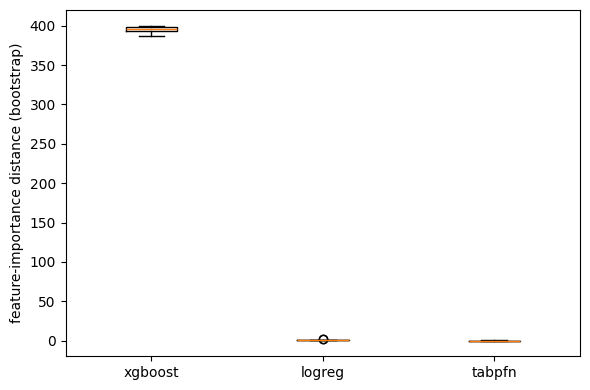

In [7]:
plottable = {name: r["importance_distance"] for name, r in stability_results.items() if "importance_distance" in r}
if plottable:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot(list(plottable.values()), tick_labels=list(plottable.keys()))
    ax.set_ylabel("feature-importance distance (bootstrap)")
    plt.tight_layout()
    fig.savefig(NB_OUTPUT_DIR / "stability_importance_distance_boxplot.png", dpi=150, bbox_inches="tight")
    plt.show()

## Summary table — one row per model, copy-ready for the slide deck

`importance distance` (raw units) is only meaningful *within* a model — see the note above on
why xgboost/logreg/tabpfn aren't on the same scale. `importance RANK distance` is the one
that's actually comparable across models. A model that shows up with all dashes means every
metric failed for it (e.g. TabPFN's `model_version` bug) — it still gets a row rather than
silently disappearing, so a total failure is visible, not indistinguishable from "not run".

In [8]:
summary_rows = []
for name, r in stability_results.items():
    summary_rows.append({
        "model": name,
        "n_boot": N_BOOT.get(name, 30),
        "importance distance (mean, raw)": round(np.mean(r["importance_distance"]), 4) if "importance_distance" in r else "—",
        "importance distance (mean, rank)": round(np.mean(r["importance_rank_distance"]), 4) if "importance_rank_distance" in r else "—",
        "AUC spread (std)": round(np.std(r["auc_spread"]), 4) if "auc_spread" in r else "—",
        "D1→D2 distance (raw)": round(r["d1_d2_distance"], 4) if "d1_d2_distance" in r else "—",
        "D1→D2 distance (rank)": round(r["d1_d2_rank_distance"], 4) if "d1_d2_rank_distance" in r else "—",
        "parameter distance (mean)": round(np.mean(r["parameter_distance"]), 4) if "parameter_distance" in r else "—",
    })

stability_summary_df = pd.DataFrame(summary_rows)
stability_summary_df

,model,n_boot,"importance distance (mean, raw)","importance distance (mean, rank)",AUC spread (std),D1→D2 distance (raw),D1→D2 distance (rank),parameter distance (mean)
0,xgboost,30,394.9743,39.9070,0.0023,401.4537,41.9047,—
1,logreg,30,0.6852,3.4372,0.0009,0.4735,2.8284,0.6889
2,tabpfn,10,0.1069,18.0030,0.0023,0.1052,16.9115,—


## Smoke test — remove once real models are in `models/`

Same throwaway logistic regression as the interpretability notebook, on a small
sample and few bootstrap iterations, purely to check the harness runs.

In [9]:
if not stability_results:
    print("Running a throwaway smoke test — NOT a real model, just checking the harness works end to end.")
    sample = train_df.sample(20_000, random_state=42)
    Xs, ys = cm.get_X_y(sample)
    test_sample = test_df.sample(2_000, random_state=42)
    Xt, yt = cm.get_X_y(test_sample)
    smoke_imp, smoke_rank_imp, smoke_auc = stability_bootstrap("logreg", cm.SmokeTestModule, "logreg", Xs, ys, Xt, yt, n_boot=5)
    print("Smoke test importance distances:", smoke_imp, "— harness is wired correctly.")

## Save outputs

Writes to `outputs/evaluation/stability/` (gitignored, same as `models/` and `data/`) so
results survive independently of the notebook. Individual metrics are already checkpointed
as they run (see above); this just writes the final consolidated summary + full results for
convenience.

In [10]:
if stability_results:
    stability_summary_df.to_csv(NB_OUTPUT_DIR / "stability_summary.csv", index=False)
    with open(NB_OUTPUT_DIR / "stability_results.pkl", "wb") as f:
        pickle.dump(stability_results, f)
    print(f"Saved summary + full results to {NB_OUTPUT_DIR}/")

Saved summary + full results to /users/eleves-a/2025/lucca.vettori/mortgage/outputs/evaluation/stability/
